# Model Spikey observed by *Kepler* with JAXNS

In this notebook we use the Bayesian inference package [`JAXNS`](https://github.com/Joshuaalbert/jaxns), using nested sampling, to model the Kepler observation of Spikey, reduced by Smith+2016. 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Built-in
import os
import sys
import json
import copy
import datetime

# Dependencies
import scipy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from jax import numpy as jnp
import numpyro
import numpyro.distributions as dist
# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

INFO:2026-03-17 12:27:17,754:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [3]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
c = 'royalblue'

---
## 1. Model Q
---

In [73]:
# Define priors
flux = df.flux.to_numpy()
folder = 'spikey_kepler_bin1d_Q_jaxns_uniform'
priors = {
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
    # 'mean' : dist.Normal(jnp.mean(flux), 0.5),
}

# priors = {
#     'z'    : params.z,
#     't0'   : dist.Uniform(0, 3),
#     'P'    : dist.Uniform(0, 5),
#     'i'    : dist.Uniform(0, 90),
#     'e'    : dist.Uniform(0, 1),
#     'w'    : dist.Uniform(0, 360),
#     'logM1': dist.Uniform(5, 11),
#     'logM2': params.,
#     'alpha': params.alpha,
#     'L'    : params.L,
#     'vz'   : params.vz,
#     'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
#     'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
# }

In [30]:
%%time
result = bs.run_jaxns(df, params, priors, bs.drw_kernel, ofile=rdir/folder/'result.npy')

INFO:jaxns:Number of Markov-chains set to: 2000


Running over 6 devices.
--------
Termination Conditions:
no seed points left (consider decreasing shell_fraction)
--------
likelihood evals: 19552719
samples: 55110
phantom samples: 0
likelihood evals / sample: 354.8
phantom fraction (%): 0.0%
--------
logZ=-796076.19 +- 0.16
max(logL)=-796039.46
H=-36.73
ESS=946
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.9281326152381731 +- 7.8e-16 | 0.9281326152381739 / 0.9281326152381739 / 0.9281326152381739 | 0.9281326152381739 | 0.9281326152381739
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 160.0 +- 140.0 | 40.0 / 120.0 / 320.0 | 60.0 | 60.0
--------
CPU times: user 1min 26s, sys: 1.25 s, total: 1min 28s
Wall time: 23.6 s


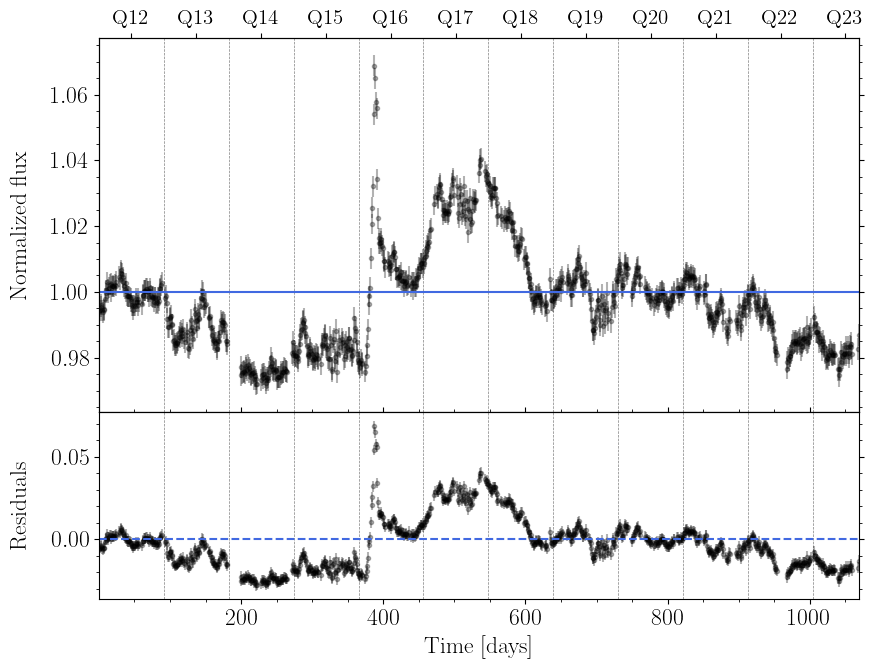

In [35]:
dm = df.copy()
dm.flux = df.flux*0 + 1
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3);
# fig = pt.plot_corner(result, best_params='map', true_params=True, color=c);

---
## 2. Model DM
---

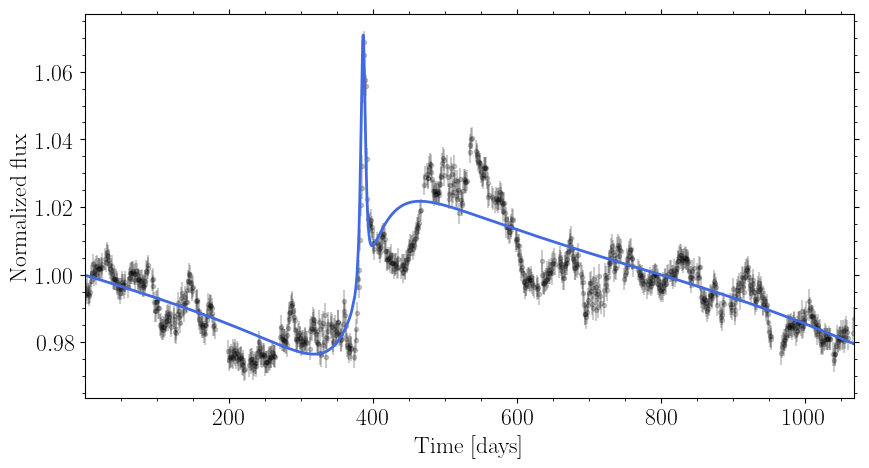

In [8]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_QDM_kepler_smith2016.csv')
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Create a 1-d binned light curve and plot
df = ut.bin_lc(df, bin_size=1)
time = df.time.to_numpy()

# Plot light curve
fig, ax = pt.plot_lc(df, dm, cm=c, alpha=0.2);

In [13]:
odir = rdir/'spikey_kepler_bin1d_DM_jaxns_uniform'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
}

In [1]:
# %%time
# result = bs.run_jaxns(df, params, priors, bs.smbhb_mean_builder, ofile=odir/'result.npy')

In [14]:
# CPU times: user 10h 14s, sys: 4min 55s, total: 10h 5min 9s
# Wall time: 1h 38min 14s
result = ut.load_result(odir/'result.npy')

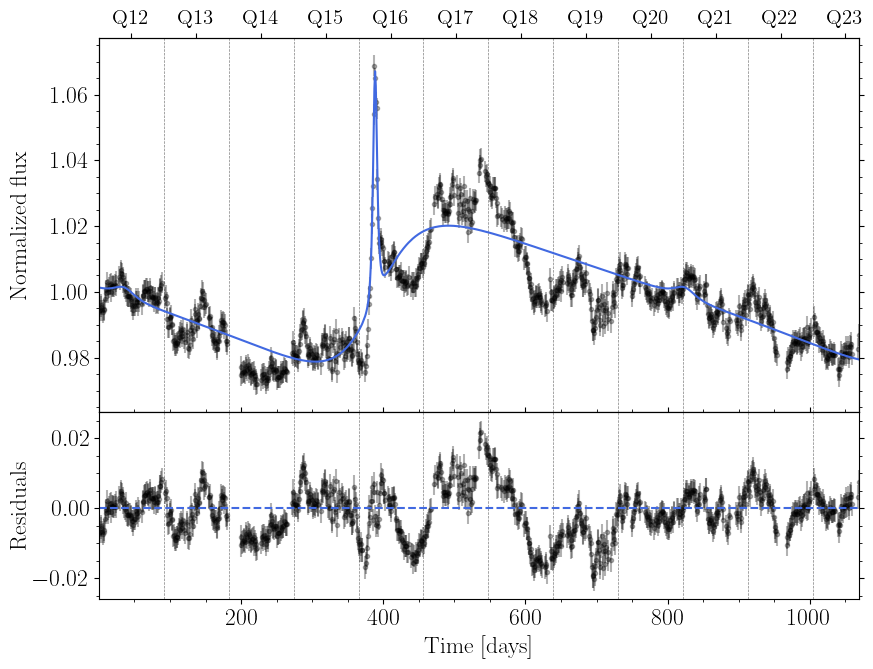

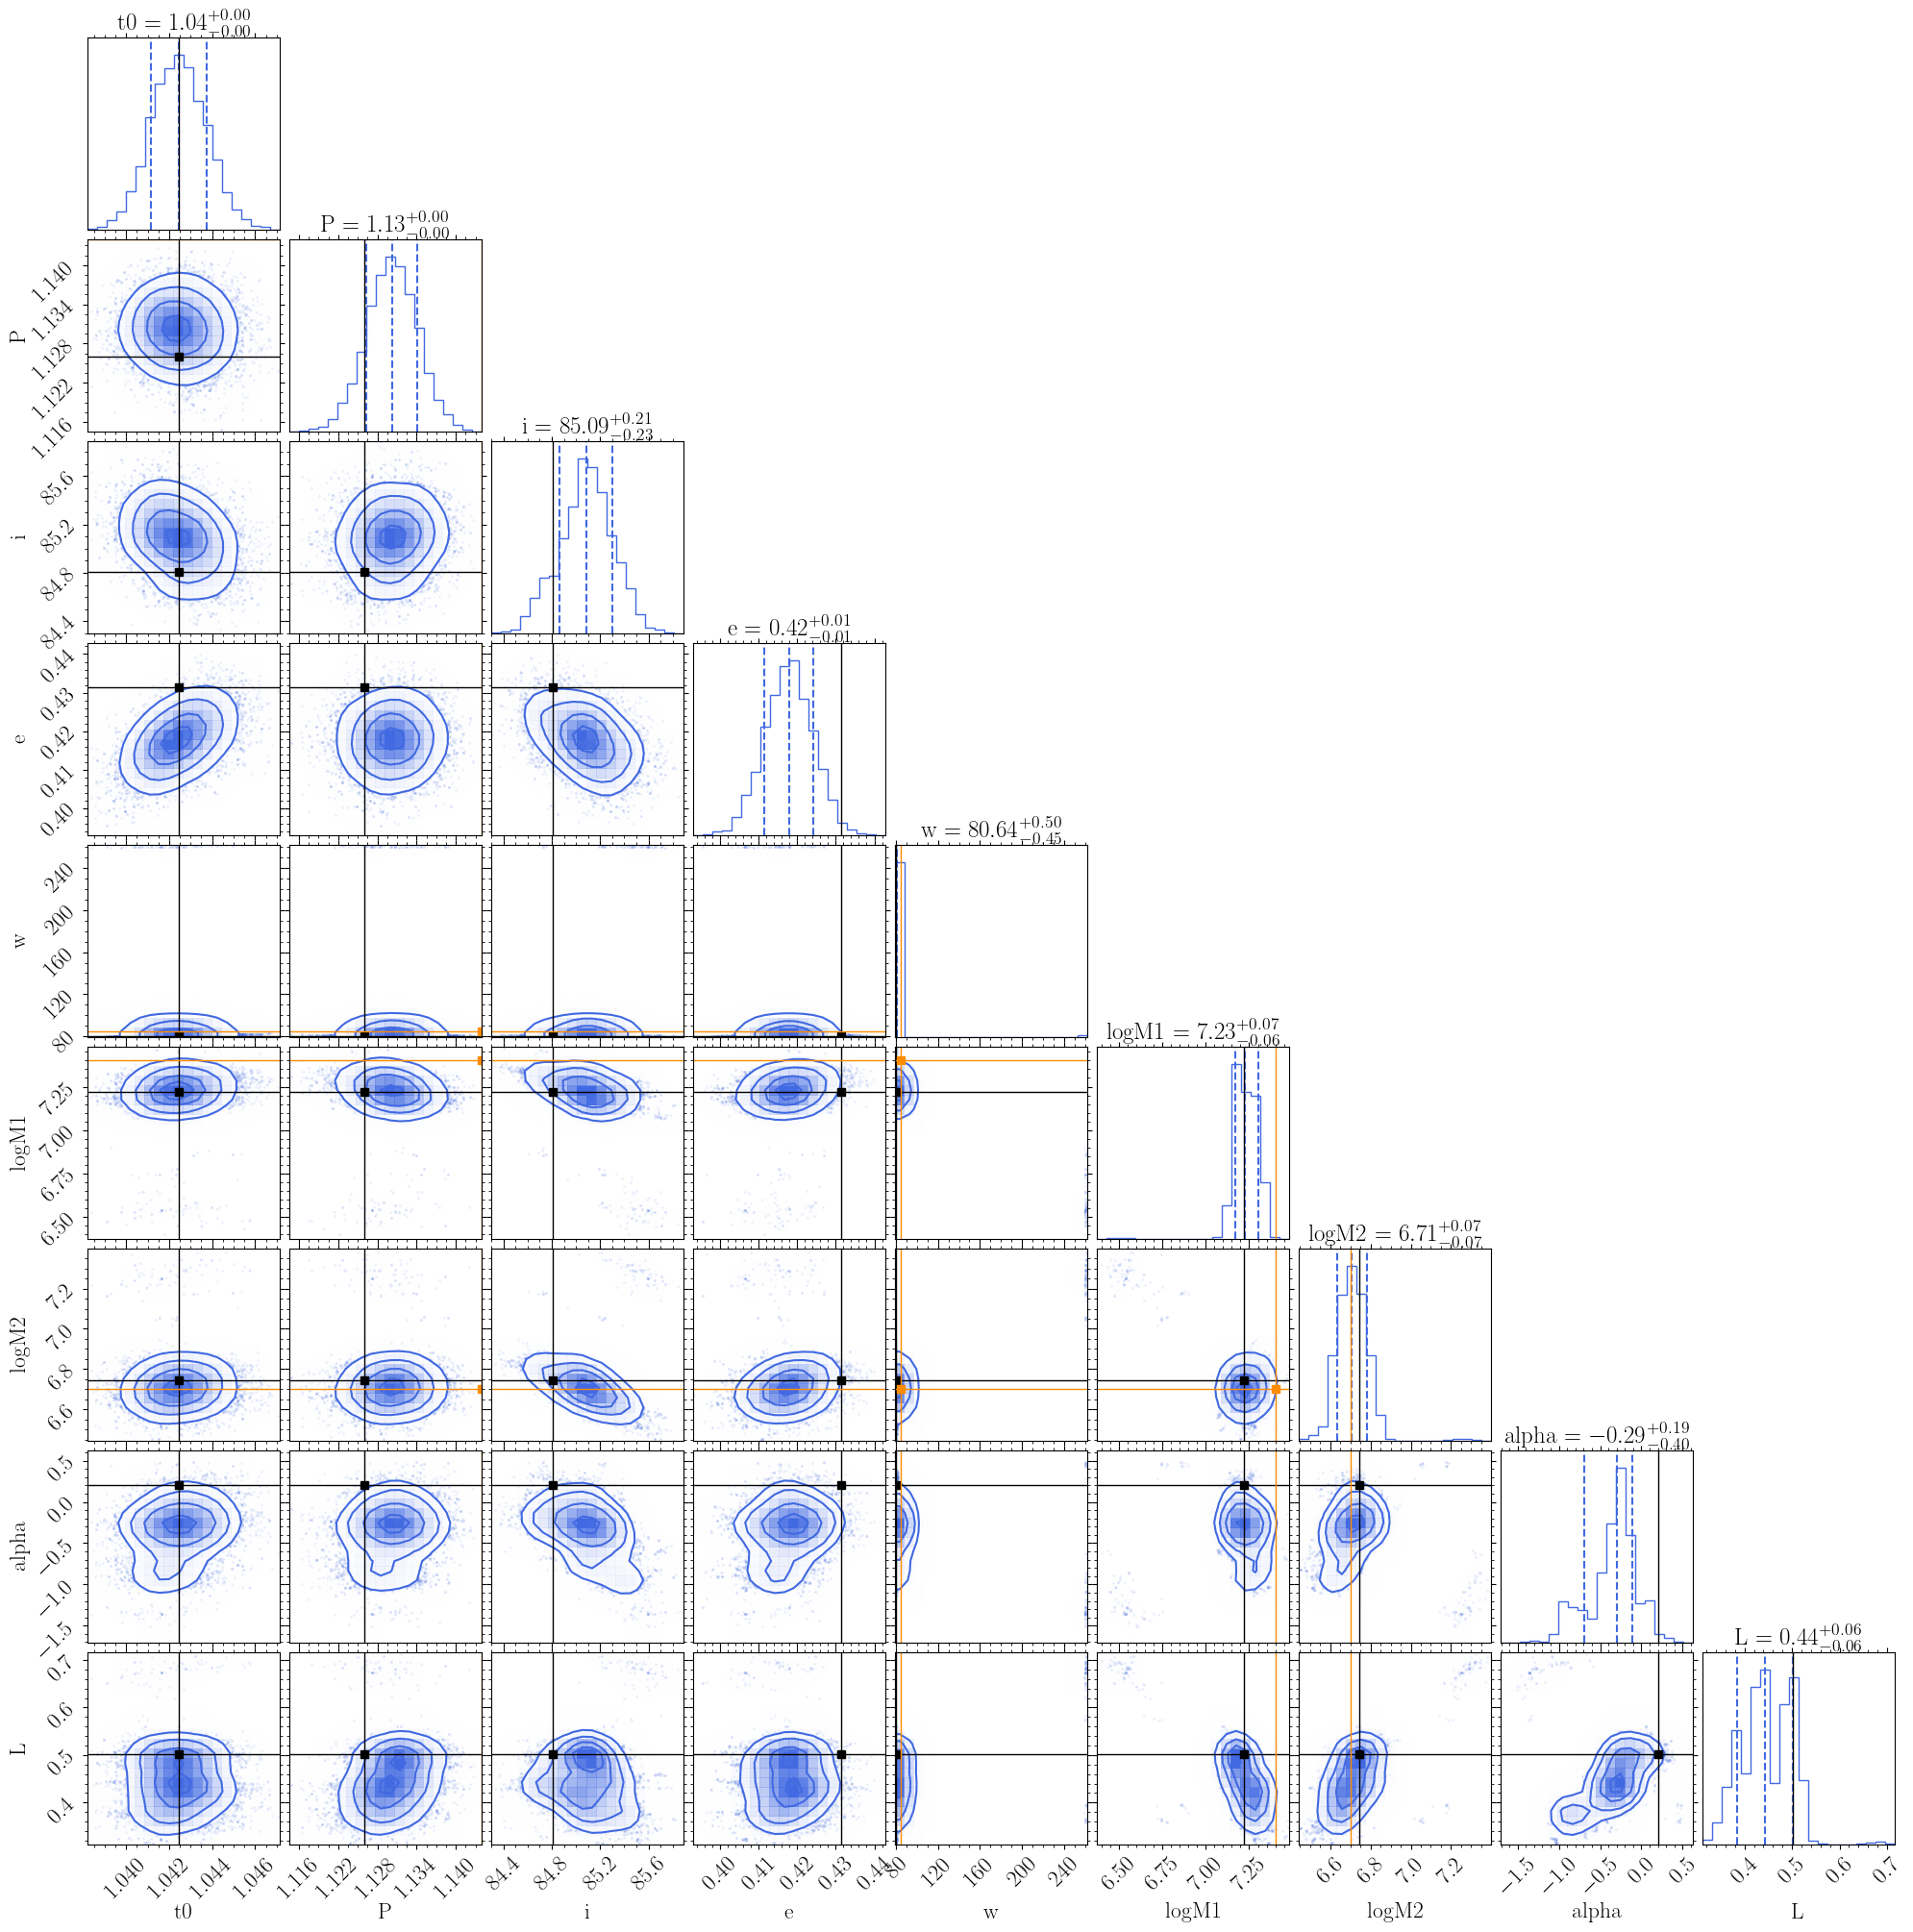

In [16]:
# Show results
dm = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3)
fig.savefig(odir/'bestfit_w.png', bbox_inches='tight', dpi=200)
fig = pt.plot_corner(result, best_params='mle', true_params=True, color=c);
fig.savefig(odir/'conerplot_w.png', bbox_inches='tight', dpi=200)

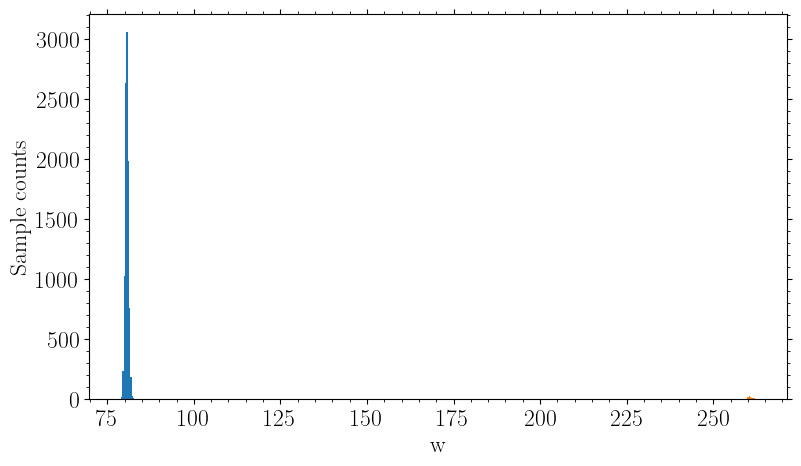

In [17]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)

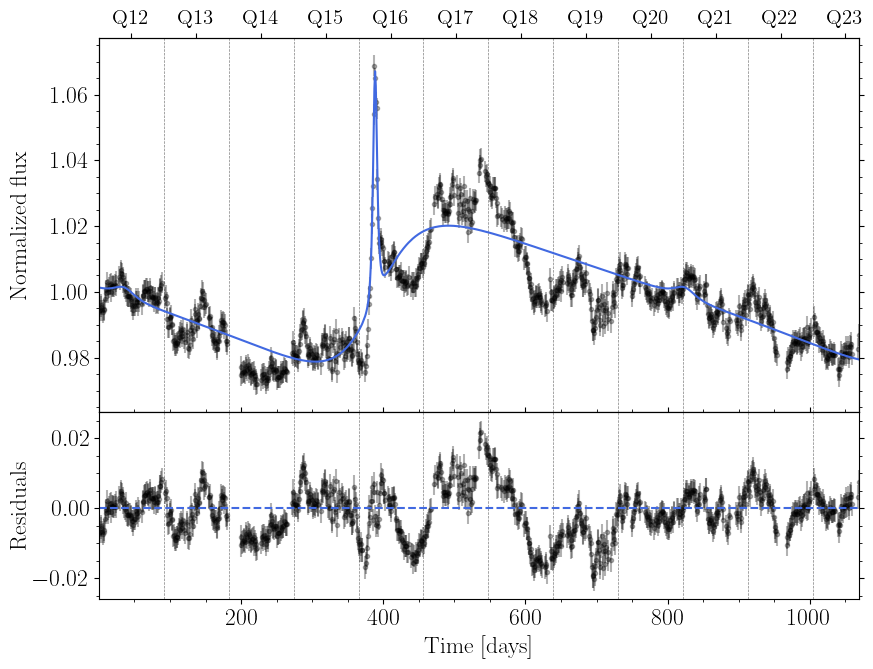

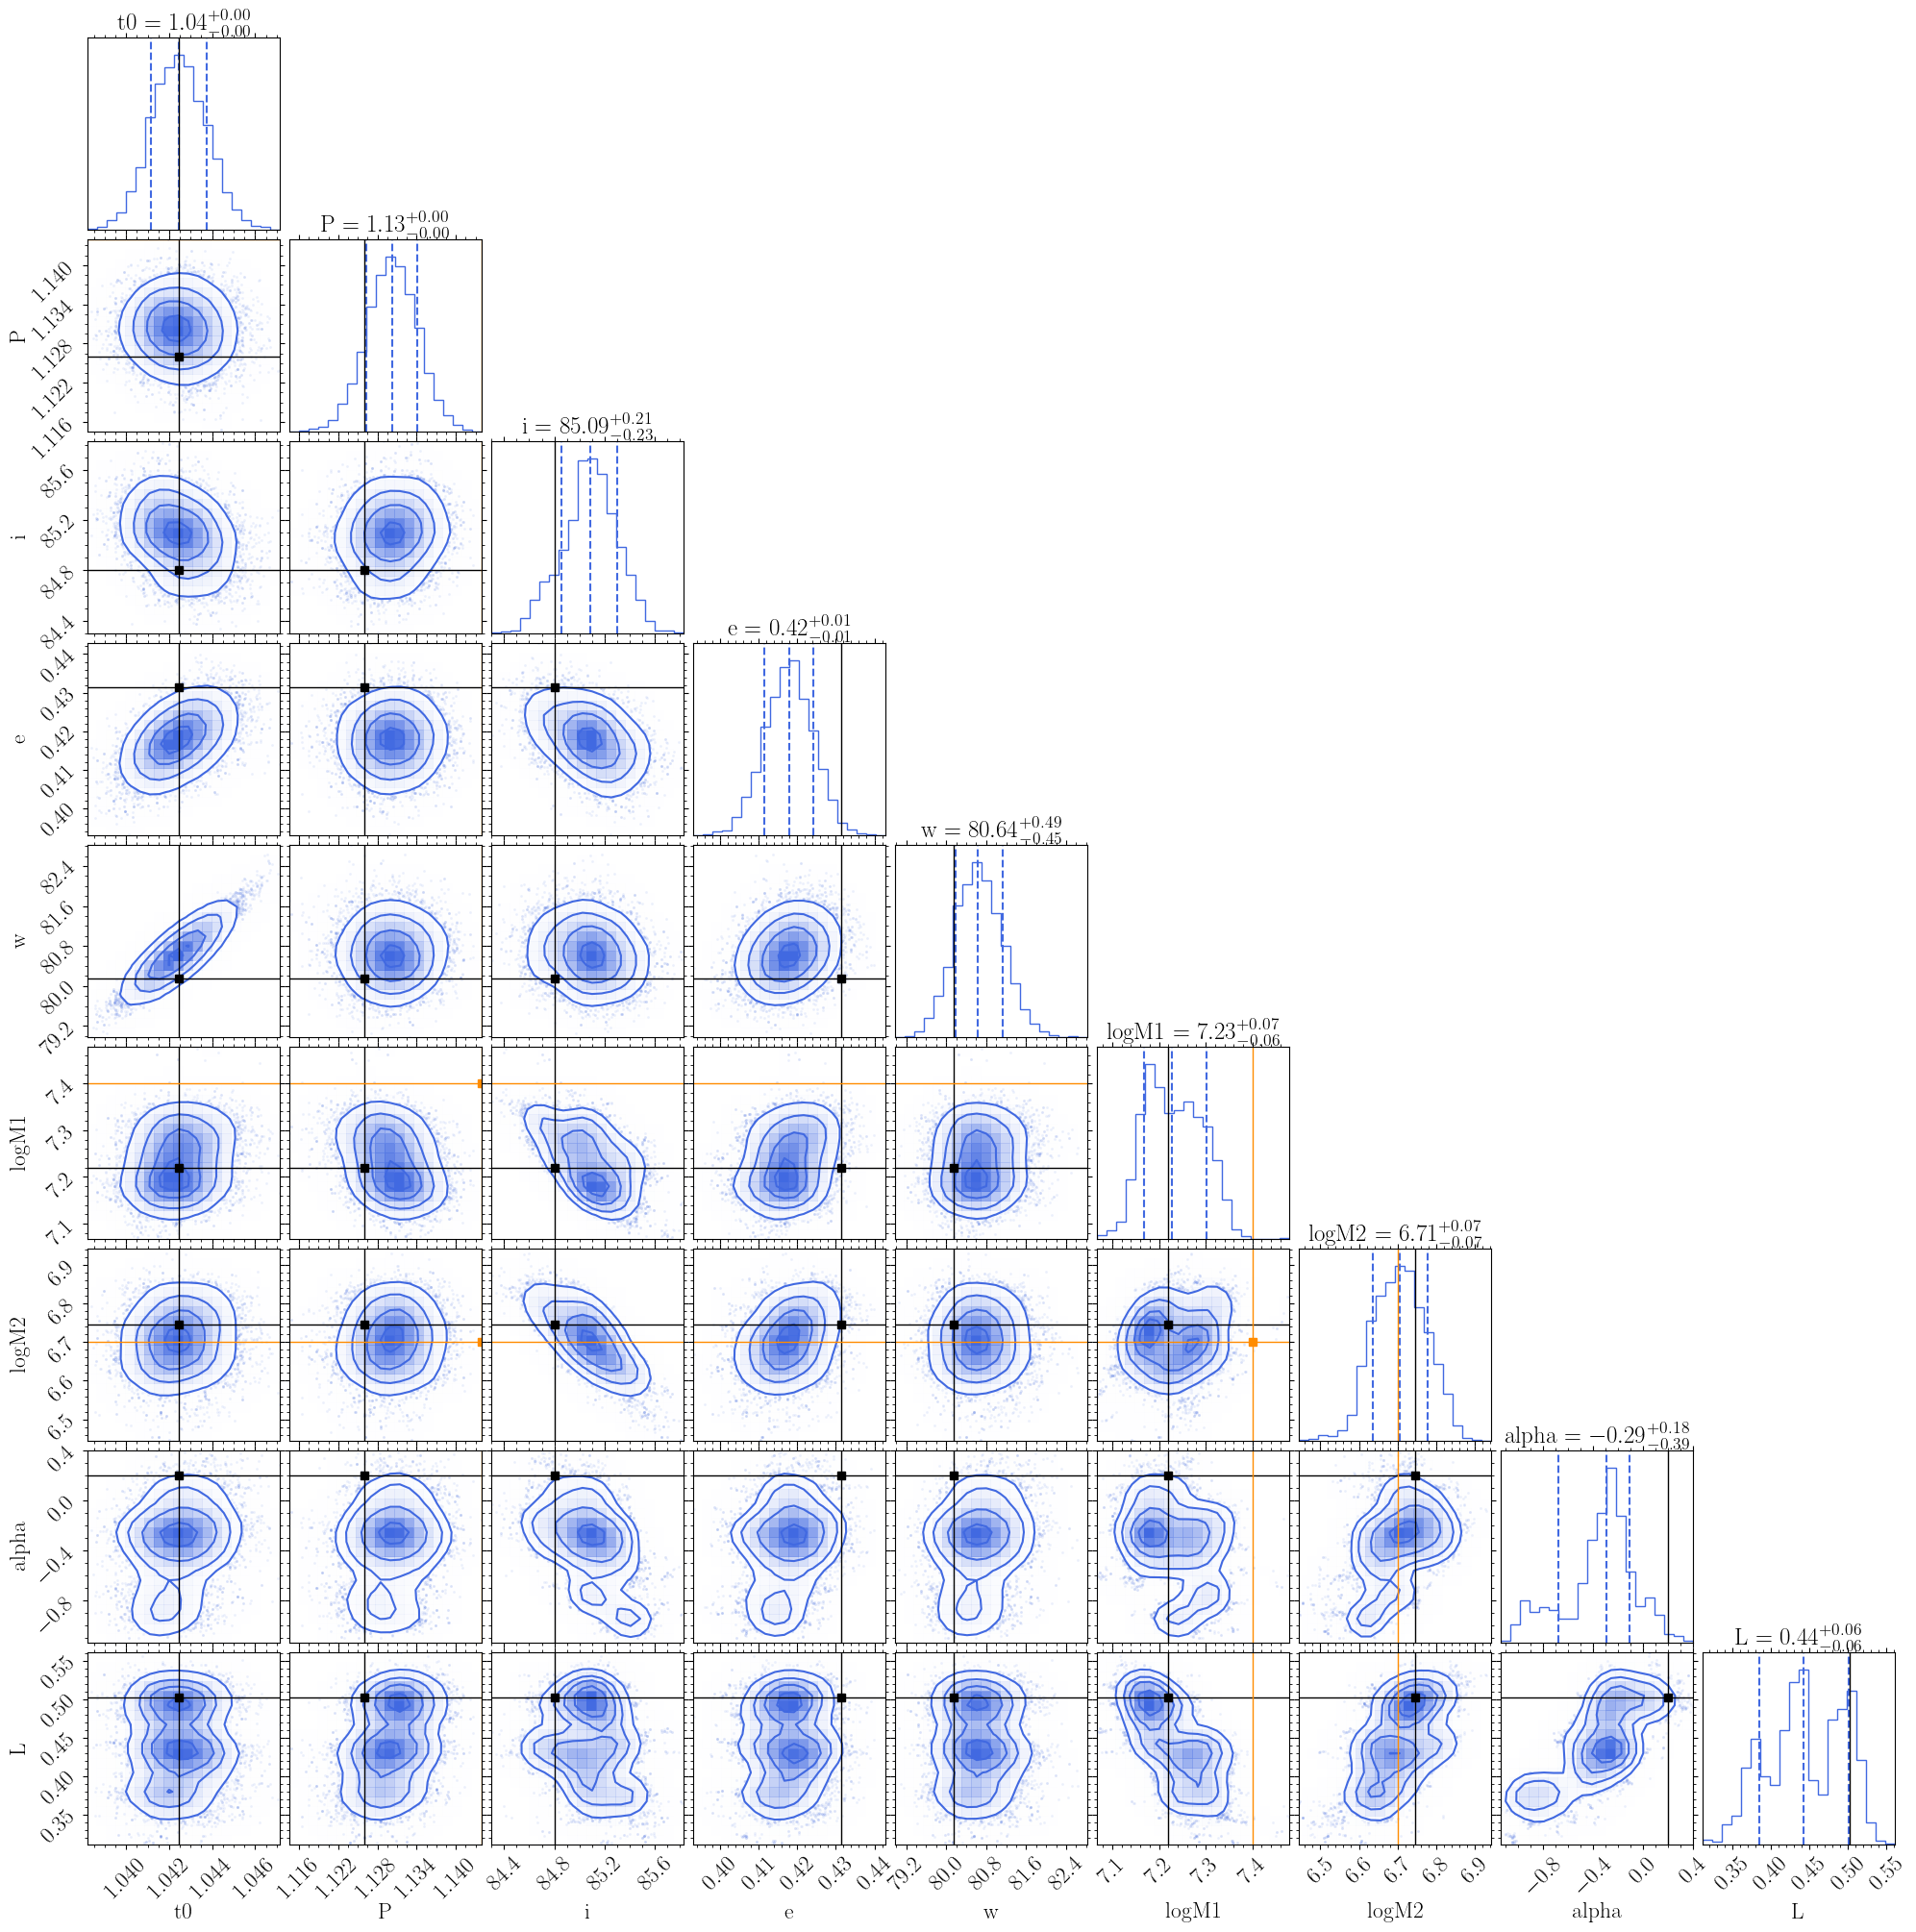

In [18]:
# Plot cluster w0
result_w0 = clusters_w[0] 
dm = smbhb.model_lightcurve(time, result_w0['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3);
fig.savefig(odir/'bestfit_w0.png', bbox_inches='tight', dpi=200)
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c)
# fig.savefig(odir/'conerplot.png', bbox_inches='tight', dpi=200)

In [80]:
# # Plot cluster w1
# result_w1 = clusters_w[1]
# dm = smbhb.model_lightcurve(time, result_w1['likelihood']['mle'])
# fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3);
# fig = pt.plot_corner(result_w1, best_params='map', true_params=True, color=c);

---
## 3. Model QDM
---

In [ ]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_QDM_kepler_smith2016.csv')
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Create a 1-d binned light curve and plot
df = ut.bin_lc(df, bin_size=1)
time = df.time.to_numpy()

# Plot light curve
fig, ax = pt.plot_lc(df, dm, cm=c, alpha=0.2);

In [ ]:
# We use wide uninformative uniform priors
odir = rdir/'spikey_kepler_bin1d_QDM_jaxns_uniform'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
}